# E · 피처 확장 (Pitch Predict 차용) + 고강도 튜닝

**차용 출처**: Josh Mancuso, *Pitch Predict* Part 1–3 (Analytics Vidhya)

**추가한 피처** (전부 `shift(1)` expanding — 투구 전 시점 안전)
| 그룹 | 내용 |
|---|---|
| `batter_scout` | **타자 스카우팅 리포트** — 구종 카테고리(fb/br/off)별 상대빈도·헛스윙률·콜스트라이크허용률·chase률·스윙률 (+표본수) |
| `gameflow` | 직전 3구의 존/스윙/CSW 여부, 최근 5·15구의 카테고리 비율·스트라이크율 |
| `prior_ab` | 직전 타석 결과 플래그 (삼진·볼넷/사구·안타·홈런 직후) |
| `lineup` | 타순 슬롯 근사 |

원문과의 차이: 원문은 **월별 순차 집계**로 누수를 막았지만, 여기서는 **투구 단위 expanding + shift(1)** 로 더 촘촘하게 처리했다.
구종은 원문처럼 **3개 카테고리**(fastball/breaking/offspeed)로 묶어 희소성을 줄였다.

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V3 = Path("out/v3")
meta = json.load(open("cache/meta.json")); df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = {"league_mean": 0.5957, "count_only": 0.5790}
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 basic {len(meta['basic_feats'])} "
      f"/ derived {len(meta['derived_feats'])} / +PitchPredict {len(meta['pp_feats'])} = full {len(meta['full_feats'])}")

train 238,054 / test 94,150 | 피처 basic 36 / derived 205 / +PitchPredict 52 = full 257


## 1. 단계적 Ablation — 어느 그룹이 실제로 기여하나

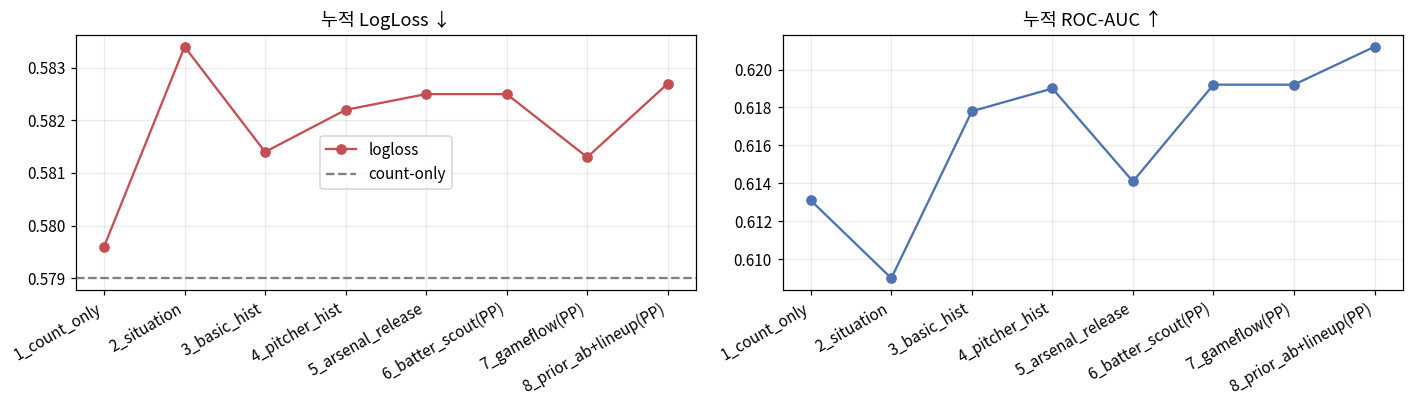

,logloss,roc_auc,pr_auc,n_feats
1_count_only,0.5796,0.6131,0.3677,8.0
2_situation,0.5834,0.6090,0.3776,71.0
3_basic_hist,0.5814,0.6178,0.3789,121.0
4_pitcher_hist,0.5822,0.6190,0.3774,247.0
5_arsenal_release,0.5825,0.6141,0.3719,290.0
6_batter_scout(PP),0.5825,0.6192,0.3803,320.0
7_gameflow(PP),0.5813,0.6192,0.3796,337.0
8_prior_ab+lineup(PP),0.5827,0.6212,0.3823,342.0


In [2]:
A = json.load(open(V3/"E_ablation.json"))
a = pd.DataFrame(A).T[["logloss","roc_auc","pr_auc","n_feats"]]
fig, ax = plt.subplots(1,2, figsize=(13,3.8))
a["logloss"].plot(marker="o", ax=ax[0], color="#C44E52"); ax[0].axhline(BASE["count_only"], ls="--", c="gray", label="count-only")
ax[0].set_title("누적 LogLoss ↓"); ax[0].legend(); plt.setp(ax[0].get_xticklabels(), rotation=30, ha="right")
a["roc_auc"].plot(marker="o", ax=ax[1], color="#4C72B0"); ax[1].set_title("누적 ROC-AUC ↑")
plt.setp(ax[1].get_xticklabels(), rotation=30, ha="right"); plt.tight_layout(); plt.show()
a

**읽는 법**: 피처를 더할수록 **AUC(순위 능력)는 오르지만 LogLoss(확률 품질)는 개선되지 않는다.**
즉 새 피처가 순서는 조금 더 잘 매기지만 확률 보정은 나빠진다 → 과적합 경향. 튜닝으로 이를 잡아본다.

## 2. Optuna 40 trials (LogLoss 최소화, 경기그룹 fold)

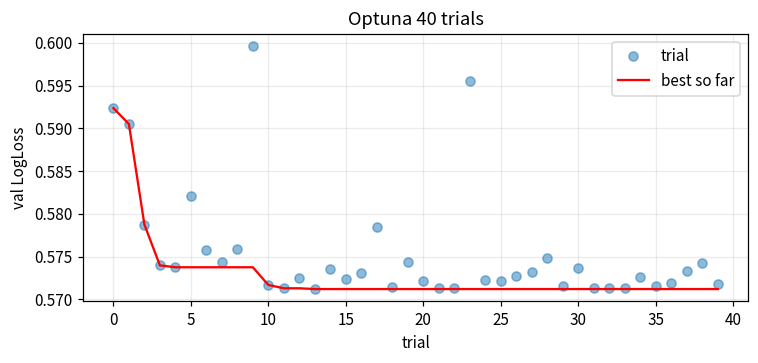

best CV: 0.57121 → TEST: 0.5734 | AUC 0.6332


,best_params
n_estimators,350.000000
learning_rate,0.020063
num_leaves,15.000000
min_child_samples,360.000000
subsample,0.604733
colsample_bytree,0.538481
reg_lambda,5.600544
reg_alpha,0.069139


In [3]:
O = json.load(open(V3/"E_optuna.json"))
h = pd.Series(O["history"]); best = h.cummin()
fig, ax = plt.subplots(figsize=(7,3.4))
ax.plot(h.values, "o", alpha=.5, label="trial"); ax.plot(best.values, "-", c="r", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("val LogLoss"); ax.set_title(f"Optuna {O['n_trials']} trials"); ax.legend()
plt.tight_layout(); plt.show()
print("best CV:", O["best_cv_logloss"], "→ TEST:", O["test_2019"]["logloss"], "| AUC", O["test_2019"]["roc_auc"])
pd.Series(O["best_params"]).to_frame("best_params")

## 3. 최종 비교

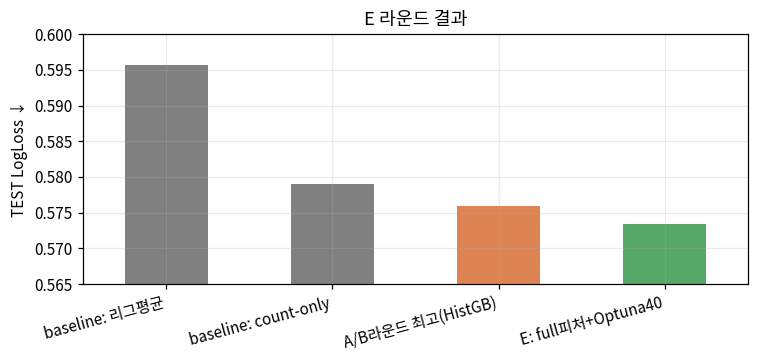

,logloss
baseline: 리그평균,0.5957
baseline: count-only,0.5790
A/B라운드 최고(HistGB),0.5760
E: full피처+Optuna40,0.5734


In [4]:
rows = {"baseline: 리그평균": {"logloss": BASE["league_mean"]}, "baseline: count-only": {"logloss": BASE["count_only"]},
        "A/B라운드 최고(HistGB)": {"logloss": 0.5760},
        "E: full피처+Optuna40": {"logloss": O["test_2019"]["logloss"]}}
t = pd.DataFrame(rows).T
ax = t["logloss"].plot.bar(figsize=(7,3.4), color=["gray","gray","#DD8452","#55A868"])
ax.set_ylim(0.565, 0.60); ax.set_ylabel("TEST LogLoss ↓"); plt.xticks(rotation=15, ha="right")
plt.title("E 라운드 결과"); plt.tight_layout(); plt.show()
t